# Weather Prediction Project: Notebook 5. Model Refinement After Selection

The ranking and selection stage has already been completed. From this point onward, the project is no longer shopping broadly among model families. Instead, it concentrates on improving the retained pair, with the baseline model kept mainly as a reference and the stronger CatBoost model treated as the real target of optimization.

The purpose of this notebook is therefore disciplined refinement: threshold tuning, hyperparameter review, feature-set extensions, calibration, and robustness analysis are all revisited here as controlled improvement questions. By the end of the notebook, the final configuration is locked and no longer under discussion.

### Refinement evidence carried forward from the integrated studies

The refinement notebook keeps the selected final model fixed, but the earlier experiments still matter because they clarify which adjustments helped and which did not.

| Refinement question | Supporting evidence | Final handling |
| --- | --- | --- |
| Should the operating threshold stay at the default 0.50? | XGBoost, LightGBM, and neural runs all improved rain-class F1 after threshold search. | Threshold selection is treated as a validation-stage decision, not an afterthought. |
| Does resampling solve the imbalance by itself? | Weighted XGBoost outperformed oversampling and SMOTE in the time-series resampling check. | The final workflow favors class weighting, calibrated probabilities, and threshold control over automatic resampling. |
| Is probability calibration useful? | Calibrated boosted-tree studies improved the precision/recall balance at lower thresholds without creating a new overall winner. | Calibration is evaluated separately from classifier selection, with time-aware support preferred. |
| Should broader feature tables reopen model shopping? | Scaled all-feature, boosted-tree, and deep-learning studies were competitive but did not clearly displace the retained winner. | Feature and context extensions are tested as controlled refinements, not as a new uncontrolled search. |

This keeps the overall workflow tidy: exploration remains broad, but refinement becomes disciplined and anchored to the selected winner.

<!-- REFINEMENT_RANKING_TRANSITION -->
### How the ranking from notebook 4 constrains refinement

The ranking stage has already settled the broad family question. Notebook 5 therefore does not reopen KNN, SVM, Random Forest, LightGBM, XGBoost, static deep, or sequence-model competition. It uses those results only as evidence about what matters once the retained pair is fixed.

| What notebook 4 already settled | Canonical feature surface carried into notebook 5 | Consequence here |
| --- | --- | --- |
| Logistic Regression remains the interpretable benchmark. | aligned top-25 feature table | Kept only as a reference line, not re-optimized as the main target. |
| CatBoost remains the strongest classifier. | 68-feature hybrid-plus-core winner representation | Receives the threshold, retune, calibration, robustness, and explanation workflow. |
| Geo-context additions are interesting but not automatically better. | 83-feature geo-context extension of the same canonical CatBoost base | Tested only as a controlled challenger, not as a new family search. |
| Boosted-tree calibration studies matter even though they are not retained winners. | broader all-feature weather table with climate context | Inform threshold and calibration practice, but do not reopen XGBoost or LightGBM selection. |
| Neural and temporal challengers were credible but still below the winner. | 68-feature scaled high-dimensional hybrid representation or the broader scaled high-dimensional table, plus rolling 68-driver sequence views | Stay in the story as ranking context, not as active refinement branches. |

This is also where feature unification matters most. From notebook 5 onward the final workflow speaks in one canonical feature language: the locked CatBoost winner uses a 68-feature hybrid-plus-core base, controlled geo-context tests extend that base to 83 features, and every other model family is referenced back to the surface defined in notebook 2 rather than silently renamed.

<!-- INTEGRATED_REFINEMENT_MERGE -->
### Why the calibration studies matter after selection

The broader boosted-tree calibration work is not the final winner, but it directly shapes the refinement logic. It contributed three concrete lessons that the final CatBoost refinement keeps.

| Lesson carried into refinement | Evidence from the calibrated boosted-tree studies | Final consequence |
| --- | --- | --- |
| Thresholds should be tuned, not assumed. | Calibrated XGBoost moved the operating threshold down to about `0.303`, and calibrated LightGBM to about `0.293`, while both stayed near `ROC-AUC 0.89` and `F1 0.67`. | Notebook 5 treats thresholding as a formal validation-stage decision. |
| Automatic oversampling is not automatically the best answer. | Weighted original training reached average F1 about `0.6748`, ahead of `SMOTE ~0.6325` and plain oversampling around `0.5925`. | The final workflow prefers class weighting, threshold control, and calibration over reflex resampling. |
| Probability reliability deserves its own study. | Isotonic calibration improved the probability-reading story for boosted trees even though it did not create the strongest final classifier. | The final winner is judged separately as a classifier and as a calibrated probability view. |

This is why the additional boosted-tree work matters even after CatBoost wins. It forced the project to be more disciplined about thresholds, imbalance handling, and calibration rather than letting the final winner pass without those checks.

![Calibrated XGBoost reliability check](../reports/figures/integrated_evidence/integrated_xgboost_calibration_after.png)

## Step 1. Load the retained final artifacts

The refinement stage reads directly from the saved winner package so that every adjustment remains tied to the exact artifacts that support the final project conclusion.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

possible_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
PROJECT_ROOT = next(
    (
        path
        for path in possible_roots
        if (path / "models").exists() and (path / "notebooks").exists()
    ),
    Path.cwd().resolve(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.visualization.final_report_charts import (
    build_calibration_curve_chart,
    build_location_robustness_chart,
    build_robustness_time_chart,
    build_segment_bar_chart,
)

pd.options.display.float_format = "{:.4f}".format
pd.options.display.max_colwidth = 180

WINNER_DIR = PROJECT_ROOT / "models" / "final_winner_package"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
THRESHOLD_FIGURE_PATH = FIGURES_DIR / "fig_68_final_winner_threshold_curve.png"
SHAP_BAR_PATH = FIGURES_DIR / "fig_54_final_hybrid_shap_bar.png"
SHAP_BEESWARM_PATH = FIGURES_DIR / "fig_55_final_hybrid_shap_beeswarm.png"
SHAP_WATERFALL_PATH = FIGURES_DIR / "fig_56_final_hybrid_shap_waterfall.png"


def display_figure(title: str, path: Path, width: int = 1120) -> None:
    display(Markdown(f"**{title}**"))
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"_Missing figure: {path.name}_"))


final_results = pd.read_csv(WINNER_DIR / "final_model_comparison.csv")
threshold_curve = pd.read_csv(WINNER_DIR / "baseline_threshold_curve.csv")
calibration_methods = pd.read_csv(WINNER_DIR / "winner_calibration_methods.csv")
raw_curve = pd.read_csv(WINNER_DIR / "winner_uncalibrated_curve.csv")
calibrated_curve = pd.read_csv(WINNER_DIR / "winner_climate_regime_isotonic_curve.csv")
shap_importance = pd.read_csv(WINNER_DIR / "final_model_shap_importance.csv")
robustness_by_season = pd.read_csv(WINNER_DIR / "robustness_by_season.csv")
robustness_by_climate = pd.read_csv(WINNER_DIR / "robustness_by_climate_regime.csv")
robustness_by_location = pd.read_csv(WINNER_DIR / "robustness_by_location.csv")
robustness_time_windows = pd.read_csv(WINNER_DIR / "robustness_time_windows.csv")

with open(WINNER_DIR / "final_hybrid_refinement_summary.json", "r", encoding="utf-8") as file:
    refinement_summary = json.load(file)

with open(WINNER_DIR / "winner_calibration_summary.json", "r", encoding="utf-8") as file:
    calibration_summary = json.load(file)

with open(WINNER_DIR / "robustness_summary.json", "r", encoding="utf-8") as file:
    robustness_summary = json.load(file)

final_results["rank"] = pd.to_numeric(final_results["rank"], errors="coerce")
baseline_row = final_results.loc[final_results["rank"] == 1].iloc[0]

print("Project root:", PROJECT_ROOT)
print("Retained shortlist rows:", len(final_results))
print("Recommended winner:", baseline_row["display_label"])

Project root: C:\Users\user 1\Desktop\feb26_bds_int_weather
Retained shortlist rows: 5
Recommended winner: Final hybrid baseline raw


**Interpretation.** By loading the saved winner package first, the notebook forces refinement to start from evidence rather than intuition. This matters because refinement is one of the places where projects often drift: once many experiments exist, it becomes tempting to keep changing several things at once and then claim improvement without a clear reference point. Here the reference point is fixed from the start.

That discipline is especially important because the workflow has already chosen its retained pair. The aim now is not to discover another surprise winner, but to test whether threshold changes, hyperparameter retuning, feature extensions, calibration, and robustness checks materially strengthen the locked CatBoost setup.

## Step 2. Start from the retained pair and clarify their roles

The baseline model is kept for reference and interpretability. The CatBoost configuration is the true target of refinement because it is the model that survived the ranking notebook as the strongest final candidate.

In [2]:
baseline_result = refinement_summary["baseline_result"]

retained_pair = pd.DataFrame(
    [
        {
            "retained_model": "Logistic Regression",
            "role_in_refinement": "Reference baseline",
            "purpose_here": "Keeps the project grounded in an interpretable benchmark while the final model is optimized.",
        },
        {
            "retained_model": "CatBoost",
            "role_in_refinement": "Primary optimization target",
            "purpose_here": "Receives the threshold, tuning, calibration, feature, and robustness refinements because it is the stronger retained model.",
        },
    ]
)

display(retained_pair)


,retained_model,role_in_refinement,purpose_here
0,Logistic Regression,Reference baseline,Keeps the project grounded in an interpretable benchmark while the final model is optimized.
1,CatBoost,Primary optimization target,"Receives the threshold, tuning, calibration, feature, and robustness refinements because it is the stronger retained model."


**Interpretation.** The retained pair has asymmetric roles, and refinement should reflect that asymmetry. Logistic Regression stays in the workflow as a benchmark that preserves interpretability and helps quantify the price of simplicity. CatBoost receives the actual optimization effort because it is the model that could plausibly become the final deployed predictor.

Stating that explicitly prevents a common modeling mistake: reopening equal competition after a decision has already been made. The baseline is kept for comparison and accountability. The CatBoost workflow is kept for improvement.

## Step 3. Keep validation time-aware throughout the refinement stage

Refinement in a temporal forecasting project must respect chronology. Standard random cross-validation is not appropriate because it mixes past and future observations, which can introduce leakage and make the model look more stable than it really is. For that reason, the project uses time-aware validation logic: training is always carried out on earlier observations, threshold choices are made on later validation observations, and the rolling-window summaries provide the cleanest reliability evidence in this stage.

The project has already inspected the common holdout during exploration, so notebook 5 should not be read as creating a brand-new untouched final-test claim. Its methodological strength comes from forward-looking validation windows, not from pretending the shared holdout is still single-use.

In [3]:
rolling_windows = pd.read_csv(WINNER_DIR / "robustness_time_windows.csv")

time_aware_protocol = pd.DataFrame(
    [
        {
            "validation_rule": "Train only on earlier dates",
            "why_it_matters": "Prevents future observations from influencing model fitting.",
        },
        {
            "validation_rule": "Tune threshold on validation data only within each study",
            "why_it_matters": "Operating-point decisions are based on validation windows rather than by searching the common holdout in this stage.",
        },
        {
            "validation_rule": "Evaluate on future folds",
            "why_it_matters": "Mimics the real forecasting condition in which tomorrow is unknown during training.",
        },
        {
            "validation_rule": "Do not retune on the common holdout in refinement",
            "why_it_matters": "The common holdout was already viewed during exploration, so refinement relies on rolling validation for the cleaner reliability check.",
        },
    ]
)

temporal_stability = pd.DataFrame(
    [
        {
            "rolling_split_count": int(len(rolling_windows)),
            "mean_test_f1": float(rolling_windows["test_f1"].mean()),
            "std_test_f1": float(rolling_windows["test_f1"].std(ddof=1)),
            "mean_test_recall": float(rolling_windows["test_recall"].mean()),
            "std_test_recall": float(rolling_windows["test_recall"].std(ddof=1)),
            "minimum_test_f1": float(rolling_windows["test_f1"].min()),
            "maximum_test_f1": float(rolling_windows["test_f1"].max()),
        }
    ]
)

display(time_aware_protocol)
display(
    rolling_windows[
        [
            "split_name",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "test_start",
            "test_end",
            "validation_threshold",
            "test_f1",
            "test_recall",
        ]
    ]
)
display(temporal_stability)

,validation_rule,why_it_matters
0,Train only on earlier dates,Prevents future observations from influencing model fitting.
1,Tune threshold on validation data only within each study,Operating-point decisions are based on validation windows rather than by searching the common holdout in this stage.
2,Evaluate on future folds,Mimics the real forecasting condition in which tomorrow is unknown during training.
3,Do not retune on the common holdout in refinement,"The common holdout was already viewed during exploration, so refinement relies on rolling validation for the cleaner reliability check."


,split_name,train_start,train_end,valid_start,valid_end,test_start,test_end,validation_threshold,test_f1,test_recall
0,rolling_split_1,2007-11-01,2013-05-27,2013-05-27,2014-03-19,2014-03-19,2015-01-12,0.6600,0.6725,0.6525
1,rolling_split_2,2007-11-01,2014-03-19,2014-03-19,2015-01-12,2015-01-12,2015-11-10,0.5400,0.6762,0.7372
2,rolling_split_3,2007-11-01,2015-01-12,2015-01-12,2015-11-10,2015-11-10,2016-09-01,0.6200,0.6944,0.7358
3,rolling_split_4,2007-11-01,2015-11-10,2015-11-10,2016-09-01,2016-09-01,2017-06-25,0.6400,0.6770,0.6825


,rolling_split_count,mean_test_f1,std_test_f1,mean_test_recall,std_test_recall,minimum_test_f1,maximum_test_f1
0,4,0.6800,0.0098,0.7020,0.0417,0.6725,0.6944


**Interpretation.** This is the notebook’s main reliability section. The rolling expanding-window evaluation shows that the locked CatBoost winner is not relying on one fortunate split: mean holdout F1 is 0.6800 with sample standard deviation 0.0098, and mean recall is 0.7020 with sample standard deviation 0.0417 across four future-looking folds. The fold thresholds vary between 0.54 and 0.66, which is useful because it shows the operating point is selected on validation data inside each period rather than fixed after looking at the common holdout.

Methodologically, this is stronger than ordinary random cross-validation. Training always happens on earlier dates, evaluation happens on later dates, and thresholds are chosen on validation windows inside each fold. Because the common holdout was already seen earlier in the project, these rolling results are the most defensible reliability evidence in the notebook.

## Step 4. Refine the decision threshold

The retained CatBoost model is probabilistic, so the decision threshold must be defended explicitly. This step keeps the threshold study visible and treats the operating point as a refinement choice rather than a hidden default.

,locked_model,retained_threshold,holdout_f1,holdout_precision,holdout_recall
0,Final hybrid baseline raw,0.5800,0.6853,0.6302,0.7510


,decision_profile,decision_threshold,holdout_f1,holdout_precision,holdout_recall
0,Balanced F1 profile,0.5800,0.6853,0.6302,0.7510
1,Precision-focused profile,0.7000,0.6760,0.7155,0.6406
2,Recall-focused profile,0.3000,0.6025,0.4518,0.9042


_The dashed vertical line in the figure marks the retained validation-selected threshold._

**Threshold profiles for the locked CatBoost winner**

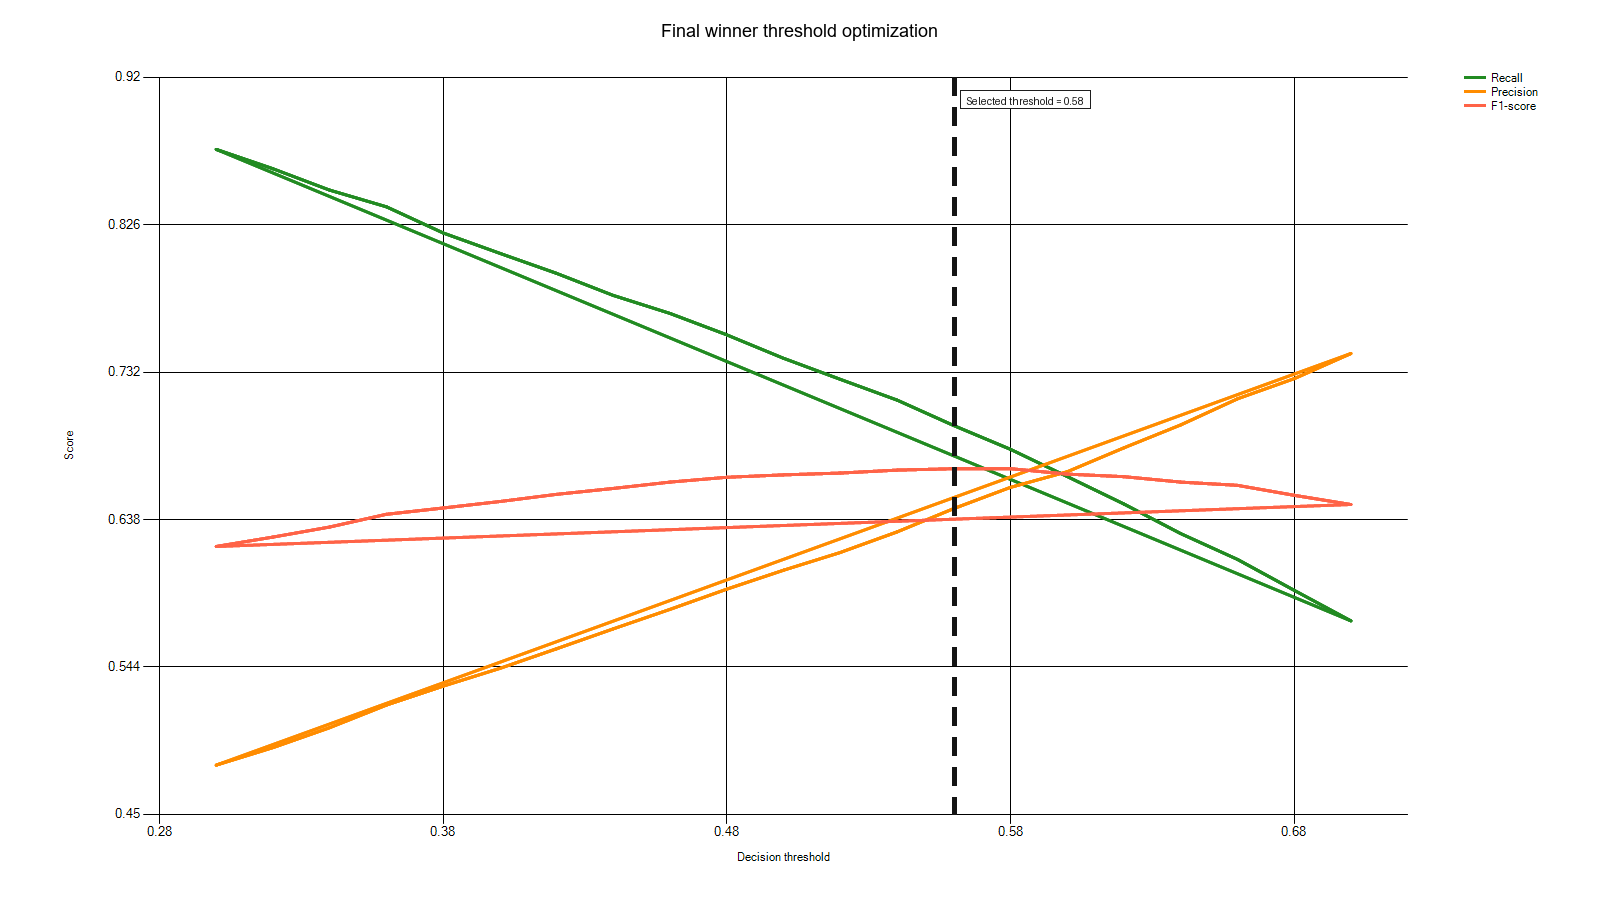

In [4]:
threshold_profiles = pd.DataFrame(refinement_summary["threshold_profiles"])[
    ["selection_metric", "threshold", "test_f1", "test_precision", "test_recall"]
].rename(
    columns={
        "selection_metric": "decision_profile",
        "threshold": "decision_threshold",
        "test_f1": "holdout_f1",
        "test_precision": "holdout_precision",
        "test_recall": "holdout_recall",
    }
)
threshold_profiles["decision_profile"] = threshold_profiles["decision_profile"].map(
    {
        "f1": "Balanced F1 profile",
        "precision": "Precision-focused profile",
        "recall": "Recall-focused profile",
    }
)

locked_threshold = pd.DataFrame(
    [
        {
            "locked_model": "Final hybrid baseline raw",
            "retained_threshold": baseline_result["selection_threshold"],
            "holdout_f1": baseline_result["test_f1"],
            "holdout_precision": baseline_result["test_precision"],
            "holdout_recall": baseline_result["test_recall"],
        }
    ]
)

display(locked_threshold)
display(threshold_profiles)
display(Markdown("_The dashed vertical line in the figure marks the retained validation-selected threshold._"))
display_figure("Threshold profiles for the locked CatBoost winner", THRESHOLD_FIGURE_PATH)

**Interpretation.** The threshold study shows that the decision rule is not arbitrary. At the locked threshold 0.58, the final winner reaches holdout F1 0.6853 with precision 0.6302 and recall 0.7510. Lowering the threshold toward the recall-focused region raises sensitivity further, but it comes with a visible fall in precision and overall F1. Raising it toward the precision-focused region improves purity, but too many rainy days are then missed.

So the retained threshold is defensible because it matches the project objective rather than because 0.5 is a standard default. It is the point where the model keeps strong rain detection without letting false alarms dominate the classification behavior.

## Step 5. Read hyperparameter tuning as a controlled optimization step

Once the stronger model has been retained, hyperparameter tuning becomes a focused question: does a more expensive or slightly different CatBoost configuration provide a meaningful improvement, or does it mainly add complexity without changing the conclusion?

In [5]:
param_review = pd.DataFrame([
    {
        "candidate": "Locked final hybrid baseline",
        **refinement_summary["baseline_params"],
    },
    {
        "candidate": "Compact retuned CatBoost challenger",
        **refinement_summary["retuned_params"],
    },
])

baseline_result = refinement_summary["baseline_result"]
refinement_results = pd.read_csv(refinement_summary["results_path"])
retuned_row = refinement_results.loc[
    refinement_results["candidate"] == "baseline_retuned_raw"
].iloc[0]

retune_effect = pd.DataFrame([
    {
        "comparison": "Holdout ROC-AUC change",
        "baseline_locked": baseline_result["test_roc_auc"],
        "retuned_candidate": retuned_row["test_roc_auc"],
        "difference": retuned_row["test_roc_auc"] - baseline_result["test_roc_auc"],
    },
    {
        "comparison": "Holdout F1 change",
        "baseline_locked": baseline_result["test_f1"],
        "retuned_candidate": retuned_row["test_f1"],
        "difference": retuned_row["test_f1"] - baseline_result["test_f1"],
    },
    {
        "comparison": "Holdout precision change",
        "baseline_locked": baseline_result["test_precision"],
        "retuned_candidate": retuned_row["test_precision"],
        "difference": retuned_row["test_precision"] - baseline_result["test_precision"],
    },
    {
        "comparison": "Holdout recall change",
        "baseline_locked": baseline_result["test_recall"],
        "retuned_candidate": retuned_row["test_recall"],
        "difference": retuned_row["test_recall"] - baseline_result["test_recall"],
    },
])

display(param_review)
display(retune_effect)

,candidate,bagging_temperature,depth,iterations,l2_leaf_reg,learning_rate,random_strength
0,Locked final hybrid baseline,0.1560,8,400,5.1906,0.0511,0.3120
1,Compact retuned CatBoost challenger,0.1560,9,400,5.5920,0.0552,0.3120


,comparison,baseline_locked,retuned_candidate,difference
0,Holdout ROC-AUC change,0.9016,0.9021,0.0004
1,Holdout F1 change,0.6853,0.6782,-0.0071
2,Holdout precision change,0.6302,0.5920,-0.0381
3,Holdout recall change,0.7510,0.7937,0.0427


**Interpretation.** The retune result is a useful reminder that optimization has to be judged on holdout consequences, not on the fact that a search was run. The compact retuned challenger nudges ROC-AUC upward from 0.9016 to 0.9021, but its holdout F1 falls from 0.6853 to 0.6782 and its precision drops sharply from 0.6302 to 0.5920, even though recall rises to 0.7937. In practical terms, the retune buys extra rain alarms but loses the balance that made the locked winner attractive.

That is why the notebook keeps the locked configuration. A refinement that changes the error profile without producing a cleaner overall decision is not a genuine improvement. The simpler locked parameter set remains the more credible final choice.

## Step 6. Test feature extensions without reopening model shopping

Refinement can also ask whether controlled feature additions make the retained CatBoost setup stronger. Here the question is narrow: do the geo-context additions improve the retained winner cleanly, or do they mostly shift the precision-recall balance without producing a true overall gain?

In [6]:
feature_extension_view = final_results.loc[
    final_results["model_view"].isin(["final_hybrid_baseline_raw", "geo_context_challenger"]),
    [
        "display_label",
        "selection_basis",
        "selection_threshold",
        "test_roc_auc",
        "test_f1",
        "test_precision",
        "test_recall",
        "delta_vs_final_baseline_f1",
    ],
].rename(
    columns={
        "display_label": "candidate",
        "selection_basis": "selection_rule",
        "selection_threshold": "decision_threshold",
        "test_roc_auc": "holdout_roc_auc",
        "test_f1": "holdout_f1",
        "test_precision": "holdout_precision",
        "test_recall": "holdout_recall",
        "delta_vs_final_baseline_f1": "f1_gap_vs_winner",
    }
)

display(feature_extension_view)

,candidate,selection_rule,decision_threshold,holdout_roc_auc,holdout_f1,holdout_precision,holdout_recall,f1_gap_vs_winner
0,Final hybrid baseline raw,validation_first_chronological_split,0.5800,0.9016,0.6853,0.6302,0.7510,0.0000
2,Geo-context challenger with climate isotonic view,validation_first_plus_time_aware_calibration_check,0.3400,0.9013,0.6823,0.6270,0.7482,-0.0030


**Interpretation.** The feature-extension comparison is honest by design. The geo-context challenger is not far away numerically, with holdout ROC-AUC 0.9013 and holdout F1 0.6823, only about 0.0030 F1 behind the locked raw winner. That closeness is scientifically interesting because it suggests climate-regime context does add useful structure.

But close is not enough to justify replacement. The extension does not deliver a clear net gain, and its extra complexity would only be worthwhile if it produced a cleaner improvement in final performance or reliability. Since it does not, the notebook treats it as valuable evidence rather than as a better final model.

## Step 7. Improve probability reliability through calibration

Classification strength and probability reliability are related but not identical. This step therefore asks whether the retained CatBoost probabilities can be made more trustworthy without changing the identity of the strongest classifier.

In [7]:
raw_method = calibration_summary["uncalibrated"]
recommended_method = calibration_summary["recommended_calibrated"]

calibration_summary_view = pd.DataFrame(
    [
        {
            "probability_view": "Raw CatBoost classification view",
            "decision_threshold": raw_method["validation_threshold"],
            "holdout_roc_auc": raw_method["test_roc_auc"],
            "holdout_f1": raw_method["test_f1"],
            "holdout_brier": raw_method["test_brier"],
            "holdout_log_loss": raw_method["test_log_loss"],
        },
        {
            "probability_view": recommended_method["method_label"],
            "decision_threshold": recommended_method["validation_threshold"],
            "holdout_roc_auc": recommended_method["test_roc_auc"],
            "holdout_f1": recommended_method["test_f1"],
            "holdout_brier": recommended_method["test_brier"],
            "holdout_log_loss": recommended_method["test_log_loss"],
        },
    ]
)

calibration_review = calibration_methods[
    [
        "method_label",
        "training_scheme",
        "calibration_family",
        "segment_strategy",
        "selection_brier",
        "test_brier",
        "test_f1",
        "test_roc_auc",
    ]
].copy()
calibration_review = calibration_review.sort_values(
    ["test_brier", "test_f1"], ascending=[True, False]
).head(8)

display(calibration_summary_view)
display(calibration_review)
display(Markdown("**App-style calibration view**"))
display(build_calibration_curve_chart(raw_curve, calibrated_curve))

,probability_view,decision_threshold,holdout_roc_auc,holdout_f1,holdout_brier,holdout_log_loss
0,Raw CatBoost classification view,0.5600,0.9016,0.6813,0.1212,0.3798
1,Time-aware isotonic by climate regime,0.3400,0.9011,0.6803,0.0971,0.3149


,method_label,training_scheme,calibration_family,segment_strategy,selection_brier,test_brier,test_f1,test_roc_auc
3,Validation-block isotonic,validation_block,isotonic,global,0.0917,0.0971,0.6823,0.8988
11,Time-aware isotonic,time_series_oof,isotonic,global,0.0989,0.0971,0.6808,0.9014
9,Time-aware isotonic by climate regime,time_series_oof,isotonic,climate_regime,0.0984,0.0971,0.6803,0.9011
10,Time-aware isotonic by season,time_series_oof,isotonic,season,0.0986,0.0972,0.6801,0.9013
2,Validation-block isotonic by season,validation_block,isotonic,season,0.0908,0.0973,0.6781,0.8983
8,Time-aware isotonic by climate regime and season,time_series_oof,isotonic,climate_regime_season_hierarchical,0.0974,0.0977,0.6784,0.9002
1,Validation-block isotonic by climate regime,validation_block,isotonic,climate_regime,0.0903,0.0977,0.6809,0.8973
6,Validation-block sigmoid by season,validation_block,sigmoid,season,0.0937,0.0982,0.6808,0.8992


**App-style calibration view**

alt.Chart(...)

**Interpretation.** The calibration study sharpens the distinction between classification quality and probability reliability. The raw winner remains the best pure classifier. The recommended climate-regime isotonic calibration slightly lowers holdout F1 from 0.6853 to 0.6803 and ROC-AUC from 0.9016 to 0.9011, but it improves Brier score materially to 0.0971 and log loss to 0.3149. That trade-off is exactly what calibration is supposed to expose.

The comparison above is deliberately calibration-specific: the raw row uses its own validation-selected threshold from the calibration study (`0.56`) so it stays directly comparable with the calibrated row. The locked classification threshold from the main winner path remains `0.58` and is not being replaced here. A plain time-aware isotonic variant edges the climate-regime version on F1 and ROC-AUC alone, but this step is optimizing probability reliability rather than pure classification score, so the retained probability view keeps the climate-aware structure while staying in the best Brier band.

So the final workflow retains two legitimate views of the same model. The raw CatBoost configuration is the preferred classification view when the main goal is a binary rain or no-rain decision. The climate-regime isotonic version is the preferred probability view when the main goal is better-calibrated risk estimates.

## Step 8. Confirm that the locked winner remains robust across segments

The final configuration should not only work globally. It should also remain credible across seasons, climate regimes, and locations. The next block therefore summarizes the segment-wise robustness evidence after the refinement choices have been fixed.

In [8]:
rolling_table = pd.DataFrame([
    {
        "rolling_split_count": int(len(robustness_time_windows)),
        "mean_holdout_f1": float(robustness_time_windows["test_f1"].mean()),
        "sample_std_holdout_f1": float(robustness_time_windows["test_f1"].std(ddof=1)),
        "mean_holdout_roc_auc": float(robustness_time_windows["test_roc_auc"].mean()),
        "sample_std_holdout_roc_auc": float(robustness_time_windows["test_roc_auc"].std(ddof=1)),
        "minimum_window_f1": float(robustness_time_windows["test_f1"].min()),
        "maximum_window_f1": float(robustness_time_windows["test_f1"].max()),
    }
])

season_view = robustness_by_season[
    ["segment_value", "support", "event_rate", "roc_auc", "f1", "precision", "recall", "eligible_for_summary"]
].sort_values("f1", ascending=False)

climate_view = robustness_by_climate[
    ["segment_value", "support", "event_rate", "roc_auc", "f1", "precision", "recall", "eligible_for_summary"]
].sort_values("f1", ascending=False)

location_view = robustness_by_location[
    ["segment_value", "climate_regime", "support", "event_rate", "roc_auc", "f1", "precision", "recall", "eligible_for_summary"]
].sort_values("f1", ascending=False)

display(rolling_table)
display(season_view.drop(columns=["eligible_for_summary"]))
display(climate_view.drop(columns=["eligible_for_summary"]))
display(location_view.drop(columns=["eligible_for_summary"]).head(10))
display(Markdown("**App-style temporal robustness chart**"))
display(build_robustness_time_chart(robustness_time_windows))
display(Markdown("**App-style season-level robustness chart**"))
display(build_segment_bar_chart(season_view, "Season-level F1"))
display(Markdown("**App-style climate-regime robustness chart**"))
display(build_segment_bar_chart(climate_view, "Climate-regime F1"))
display(Markdown("**App-style location-level robustness chart**"))
display(build_location_robustness_chart(location_view))

,rolling_split_count,mean_holdout_f1,sample_std_holdout_f1,mean_holdout_roc_auc,sample_std_holdout_roc_auc,minimum_window_f1,maximum_window_f1
0,4,0.6800,0.0098,0.9037,0.0041,0.6725,0.6944


,segment_value,support,event_rate,roc_auc,f1,precision,recall
2,Winter,5657,0.2733,0.9167,0.7335,0.6647,0.8182
0,Autumn,8766,0.2126,0.9035,0.6877,0.6290,0.7586
3,Spring,5260,0.2221,0.8918,0.6724,0.6181,0.7372
1,Summer,8430,0.1934,0.8912,0.6441,0.6052,0.6883


,segment_value,support,event_rate,roc_auc,f1,precision,recall
2,Winter dominant,3457,0.2473,0.9267,0.7494,0.7152,0.7871
1,Winter,6455,0.2435,0.9089,0.7157,0.6659,0.7735
4,Summer dominant,2271,0.2624,0.8828,0.6844,0.6259,0.7550
0,Uniform,10830,0.2205,0.8869,0.6594,0.5971,0.7362
5,Summer,2200,0.2259,0.8784,0.6553,0.5699,0.7706
3,Arid,2900,0.1034,0.9199,0.6107,0.6149,0.6067


,segment_value,climate_regime,support,event_rate,roc_auc,f1,precision,recall
31,Witchcliffe,Winter dominant,576,0.2847,0.9409,0.7799,0.7179,0.8537
42,Walpole,Winter dominant,554,0.3538,0.9061,0.7651,0.7281,0.8061
6,Darwin,Summer dominant,592,0.3193,0.9110,0.7576,0.6822,0.8519
14,Nuriootpa,Winter,588,0.2092,0.9338,0.7549,0.7239,0.7886
11,Dartmoor,Winter,589,0.2869,0.9180,0.7541,0.7005,0.8166
32,PearceRAAF,Winter dominant,576,0.1823,0.9353,0.7523,0.7257,0.7810
44,WaggaWagga,Uniform,542,0.1882,0.9382,0.7463,0.7576,0.7353
15,Portland,Winter,587,0.3560,0.8891,0.7450,0.6942,0.8038
20,Adelaide,Winter,583,0.2075,0.9342,0.7448,0.7542,0.7355
0,Perth,Winter dominant,593,0.2040,0.9280,0.7417,0.7479,0.7355


**App-style temporal robustness chart**

...

alt.Chart(...)

**App-style climate-regime robustness chart**

alt.Chart(...)

**App-style location-level robustness chart**

alt.Chart(...)

**Interpretation.** The robustness results make the refinement stage much more credible. Across rolling windows, F1 stays between 0.6725 and 0.6944, with mean holdout F1 0.6800 and sample standard deviation 0.0098 across the four future-looking folds. Mean holdout ROC-AUC stays near 0.9037 with sample standard deviation 0.0041. Seasonal segmentation is also informative rather than comforting: Winter is strongest at F1 0.7335, while Summer is weaker at 0.6441. By climate regime, Winter dominant reaches 0.7494 whereas Arid falls to 0.6107. These differences are real, but they remain within a believable operational range.

This is exactly the kind of result a final refinement notebook should show. The model is not uniformly identical across every context, yet its behavior remains strong enough across seasons, regimes, and locations to support a general forecasting claim rather than a one-slice success story.

## Step 9. Interpret the locked winner with SHAP

Refinement should not end with thresholds and robustness alone. The locked winner also needs an explanation layer showing whether it relies on meteorologically sensible signals rather than opaque shortcuts. The next block therefore brings the same SHAP figures used in the app directly into the notebook.

,leading_driver,mean_absolute_shap
0,sunshine,0.6522
1,wind_gust_speed,0.3604
2,cloud_humidity_3pm_interaction,0.3352
3,pressure_3pm,0.3185
4,rainfall,0.2458
5,pressure_humidity_3pm_ratio,0.2237
6,pressure_3pm_24h_diff,0.1950
7,pressure_day_diff,0.1477


**SHAP bar view of the locked final winner**

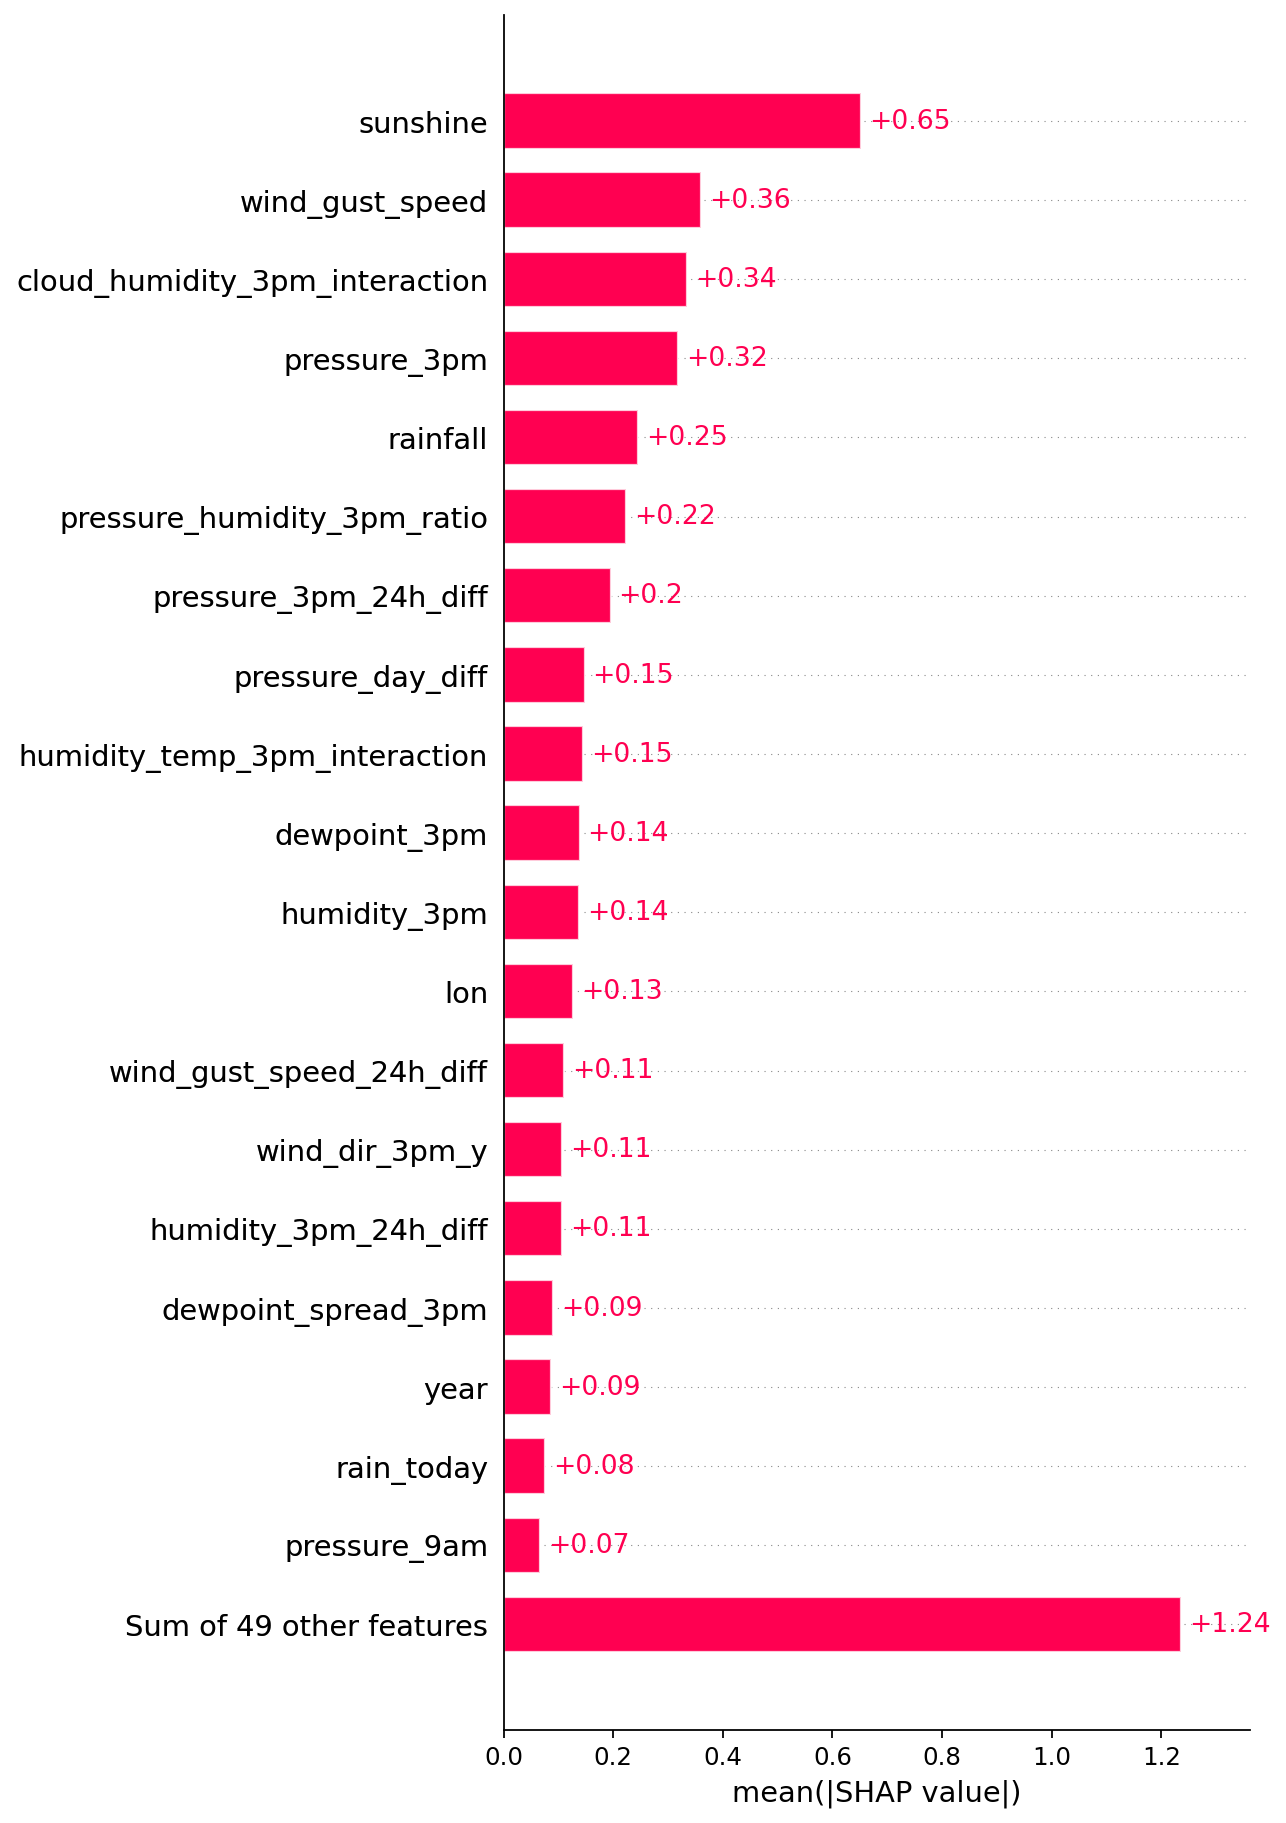

**SHAP beeswarm view of the locked final winner**

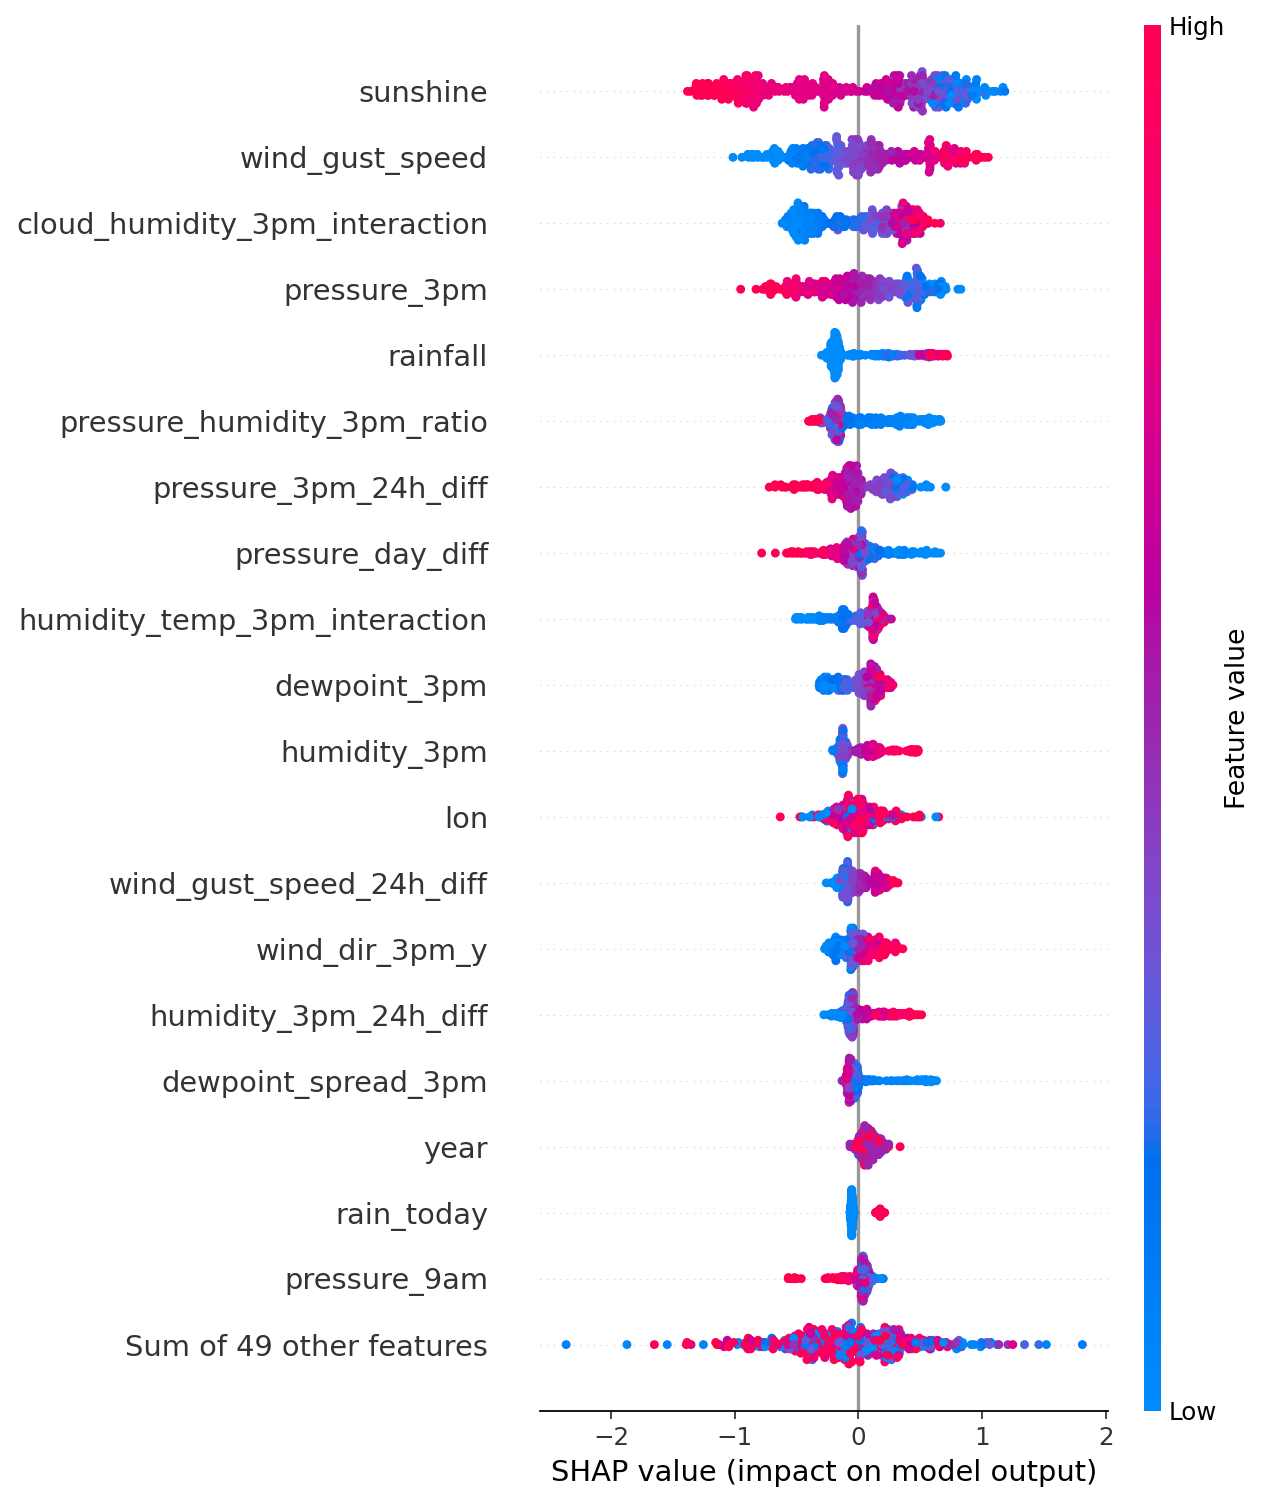

**SHAP waterfall illustration for one retained prediction**

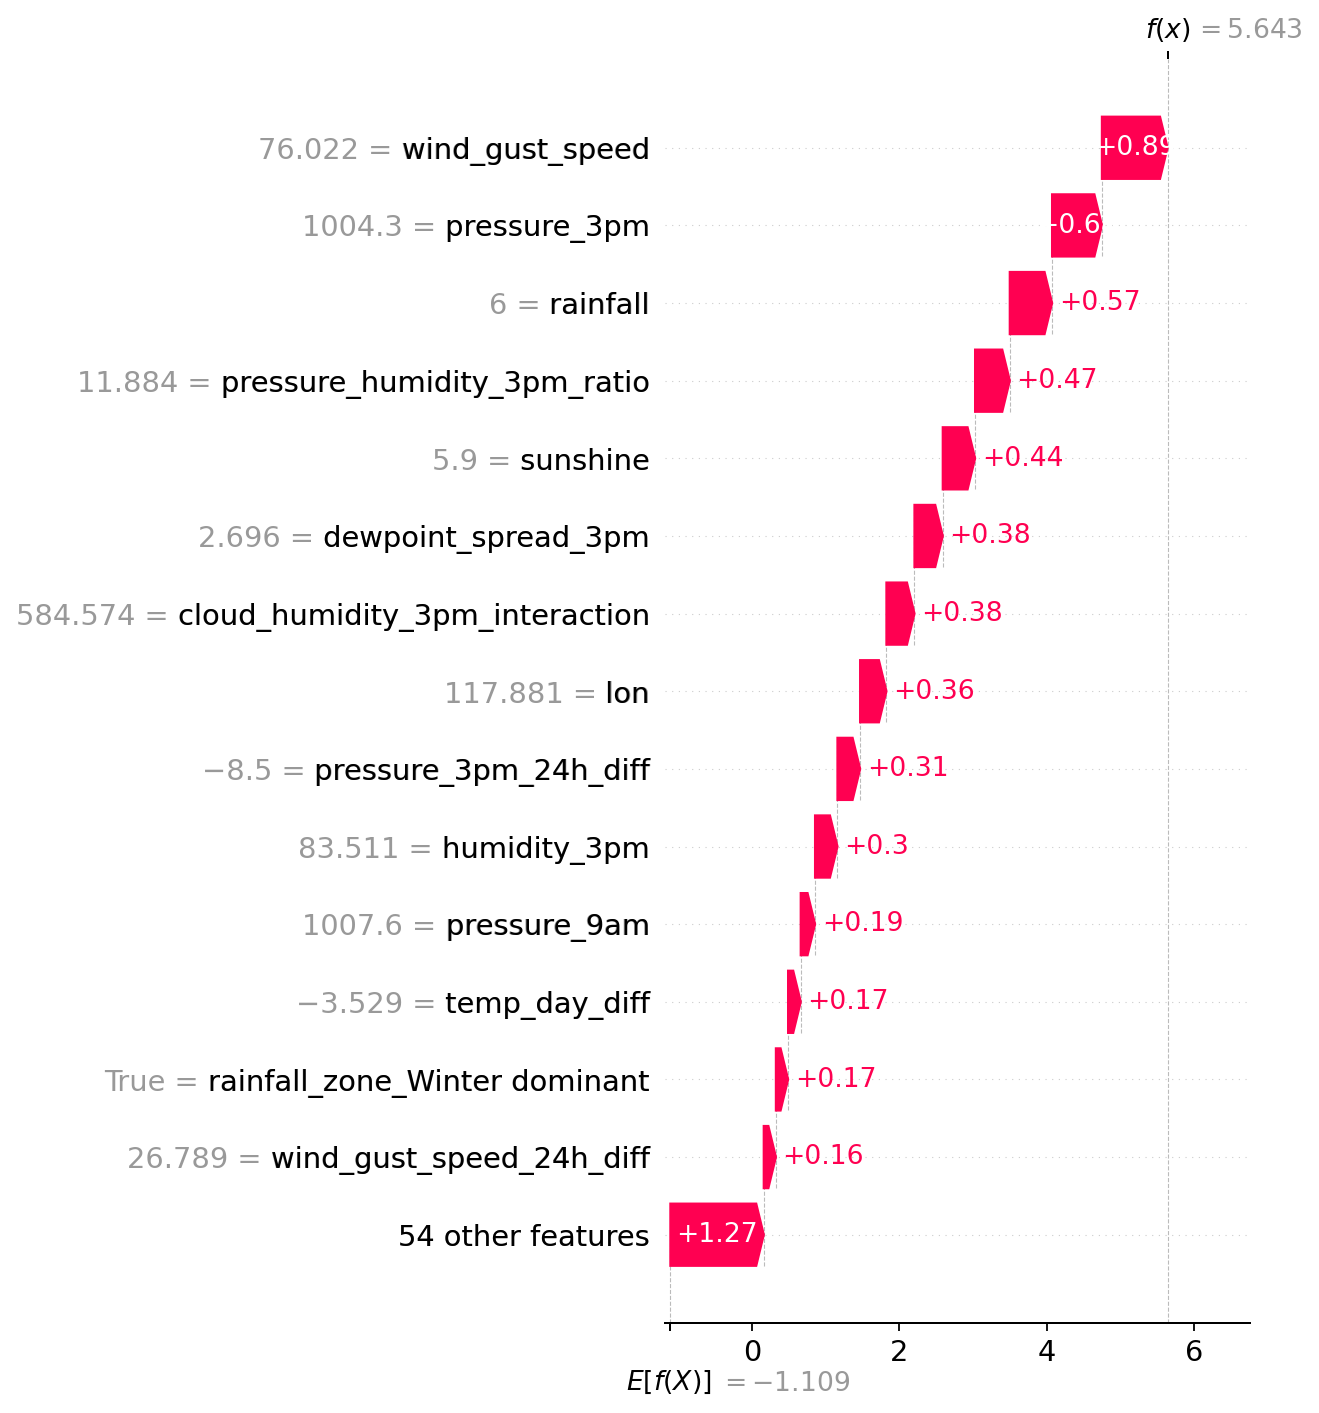

In [9]:
top_shap = shap_importance.head(8)[["feature", "mean_abs_shap"]].rename(
    columns={"feature": "leading_driver", "mean_abs_shap": "mean_absolute_shap"}
)

display(top_shap)
display_figure("SHAP bar view of the locked final winner", SHAP_BAR_PATH)
display_figure("SHAP beeswarm view of the locked final winner", SHAP_BEESWARM_PATH)
display_figure("SHAP waterfall illustration for one retained prediction", SHAP_WATERFALL_PATH)


**Interpretation.** The SHAP evidence shows that the locked winner is not strong for mysterious reasons. Sunshine, wind gust speed, the cloud-humidity interaction at 3 PM, pressure at 3 PM, and rainfall remain the dominant drivers, which is coherent with how unstable afternoon moisture, frontal pressure patterns, and recent rain accumulation shape next-day rainfall risk in Australia. The importance pattern is also useful methodologically: it confirms that the hybrid representation improved the final model by combining physically meaningful weather signals rather than by introducing arbitrary complexity.

This matters for refinement because the final recommendation has to be trustworthy as well as accurate. The calibration and robustness sections show that the model behaves consistently; the SHAP section shows that it is behaving for plausible meteorological reasons. That combination is what makes the locked CatBoost configuration credible enough to carry into the final summary.

## Step 10. Lock the final configuration

By the end of the refinement stage, the modeling setup is no longer under discussion. The retained CatBoost configuration is locked as the final predictive model, and the baseline model remains only as a reference point for interpretation and comparison.

In [10]:
locked_configuration = pd.DataFrame(
    [
        {
            "locked_model": "Final hybrid baseline raw",
            "model_family": "CatBoost",
            "retained_feature_space": "68-feature hybrid-plus-core winner representation",
            "decision_threshold": baseline_result["selection_threshold"],
            "holdout_roc_auc": baseline_result["test_roc_auc"],
            "holdout_f1": baseline_result["test_f1"],
            "holdout_recall": baseline_result["test_recall"],
            "mean_temporal_f1": float(rolling_windows["test_f1"].mean()),
            "mean_temporal_recall": float(rolling_windows["test_recall"].mean()),
        }
    ]
)

display(locked_configuration)


,locked_model,model_family,retained_feature_space,decision_threshold,holdout_roc_auc,holdout_f1,holdout_recall,mean_temporal_f1,mean_temporal_recall
0,Final hybrid baseline raw,CatBoost,68-feature hybrid-plus-core winner representation,0.5800,0.9016,0.6853,0.7510,0.6800,0.7020


**Locked conclusion.** By the end of refinement, the project is no longer choosing among broad alternatives. The final classifier is the raw CatBoost hybrid configuration with threshold 0.58, holdout ROC-AUC 0.9016, holdout F1 0.6853, and recall 0.7510. Calibration is preserved as a separate probability-improvement layer, not as a replacement winner.

That locked setup is defended by more than one score. It survives time-aware validation, it is not improved meaningfully by the retune, it is not clearly displaced by the geo-context extension, and it remains robust across multiple temporal and climatic segments. That is why the modeling discussion can now close.